# Global Spatial Autocorrelation with Moran's I

This notebook  focuses on global spatial autocorrelation for a continuous attribute using Moran's I.

## Learning goals

By the end of this notebook, you will be able to:

- construct a spatial weights matrix for areal data
- compute a spatial lag for a continuous attribute
- interpret global Moran's $I$ as a summary measure of spatial autocorrelation
- compare the observed statistic to a permutation reference distribution

The substantive question is whether neighborhoods with similar median Airbnb prices tend to be located near one another.


In [1]:
import geopandas as gpd
import libpysal as lps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import esda

Our data set comes from the Berlin airbnb scrape taken in April 2018. This dataframe was constructed as part of the [GeoPython 2018 workshop](https://github.com/ljwolf/geopython) by [Levi Wolf](https://ljwolf.org) and [Serge Rey](https://sergerey.org). As part of the workshop a geopandas data frame was constructed with one of the columns reporting the median listing price of units in each neighborhood in Berlin:

## Data preparation

We begin by assembling neighborhood polygons and Airbnb listings, then aggregate listing prices to the neighborhood level. The resulting variable, `median_pri`, is the continuous attribute we will analyze throughout the notebook.


In [2]:
gdf = gpd.read_file("data/berlin-neighbourhoods.geojson")

In [3]:
bl_df = pd.read_csv("data/berlin-listings.csv")
geometry = gpd.points_from_xy(x=bl_df.longitude, y=bl_df.latitude, crs="epsg:4326")
bl_gdf = gpd.GeoDataFrame(bl_df, geometry=geometry)

In [4]:
bl_gdf["price"] = bl_gdf["price"].astype("float32")
sj_gdf = gpd.sjoin(
    gdf, bl_gdf, how="inner", predicate="intersects", lsuffix="left", rsuffix="right"
)
median_price_gb = sj_gdf["price"].groupby([sj_gdf["neighbourhood_group"]]).mean()
median_price_gb

neighbourhood_group
Charlottenburg-Wilm.        58.556408
Friedrichshain-Kreuzberg    55.492809
Lichtenberg                 44.584270
Marzahn - Hellersdorf       54.246754
Mitte                       60.387890
Neukölln                    45.135948
Pankow                      60.282516
Reinickendorf               43.682465
Spandau                     48.236561
Steglitz - Zehlendorf       54.445683
Tempelhof - Schöneberg      53.704407
Treptow - Köpenick          51.222004
Name: price, dtype: float32

In [5]:
gdf = gdf.join(median_price_gb, on="neighbourhood_group")
gdf.rename(columns={"price": "median_pri"}, inplace=True)
gdf.head(15)

,neighbourhood,neighbourhood_group,geometry,median_pri
0,Blankenfelde/Niederschönhausen,Pankow,"MULTIPOLYGON (((13.41191 52.61487, 13.41183 52...",60.282516
1,Helmholtzplatz,Pankow,"MULTIPOLYGON (((13.41405 52.54929, 13.41422 52...",60.282516
2,Wiesbadener Straße,Charlottenburg-Wilm.,"MULTIPOLYGON (((13.30748 52.46788, 13.30743 52...",58.556408
3,Schmöckwitz/Karolinenhof/Rauchfangswerder,Treptow - Köpenick,"MULTIPOLYGON (((13.70973 52.3963, 13.70926 52....",51.222004
4,Müggelheim,Treptow - Köpenick,"MULTIPOLYGON (((13.73762 52.4085, 13.73773 52....",51.222004
5,Biesdorf,Marzahn - Hellersdorf,"MULTIPOLYGON (((13.56643 52.5351, 13.56697 52....",54.246754
6,Nord 1,Reinickendorf,"MULTIPOLYGON (((13.33669 52.62265, 13.33663 52...",43.682465
7,West 5,Reinickendorf,"MULTIPOLYGON (((13.28138 52.59958, 13.28158 52...",43.682465
8,Frankfurter Allee Nord,Friedrichshain-Kreuzberg,"MULTIPOLYGON (((13.4532 52.51682, 13.45321 52....",55.492809
9,Buch,Pankow,"MULTIPOLYGON (((13.4645 52.65055, 13.46457 52....",60.282516


We have an `nan` to first deal with:

In [6]:
pd.isnull(gdf["median_pri"]).sum()

2

In [7]:
gdf["median_pri"] = gdf["median_pri"].fillna(gdf["median_pri"].mean())

<Axes: >

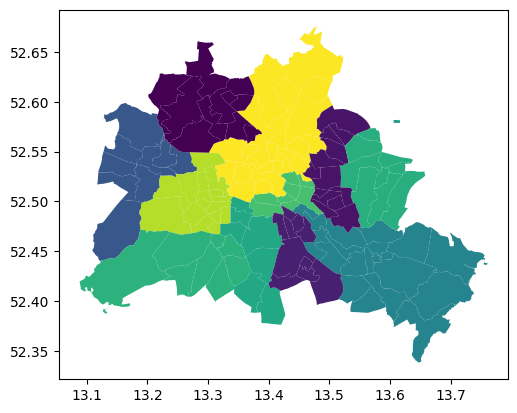

In [8]:
gdf.plot(column="median_pri")

<Axes: >

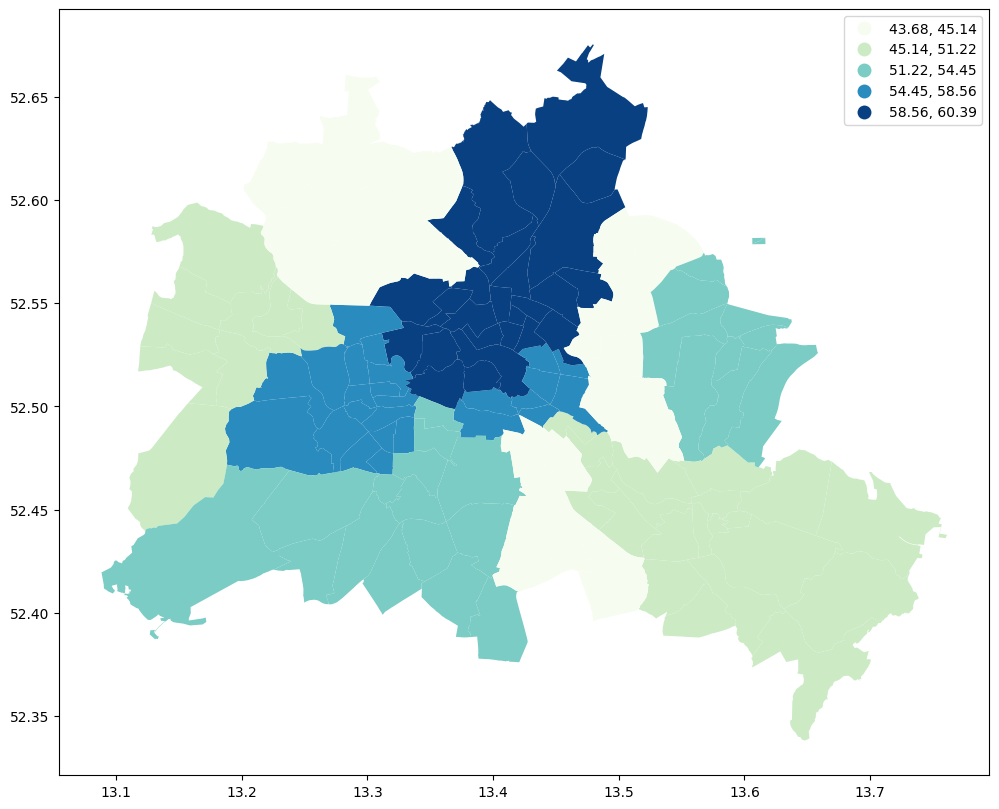

In [9]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
gdf.plot(column="median_pri", scheme="Quantiles", k=5, cmap="GnBu", legend=True, ax=ax)
# ax.set_xlim(150000, 160000)
# ax.set_ylim(208000, 215000)

## Why Moran's I?

A map can suggest clustering, but visual impressions are not enough. Moran's $I$ provides a formal global test of whether nearby areas tend to have similar values more often than would be expected under spatial randomness.


## Global Spatial Autocorrelation

### Moran's I

In [10]:
df = gdf
wq = lps.weights.Queen.from_dataframe(df, use_index=False, silence_warnings=True)
wq.transform = "r"

### Attribute Similarity
So the spatial weight between neighborhoods $i$ and $j$ indicates if the two 
are neighbors (i.e., geographically similar). What we also need is a measure of
attribute similarity to pair up with this concept of spatial similarity. The
**spatial lag** is a derived variable that accomplishes this for us. For neighborhood
$i$ the spatial lag is defined as: $$ylag_i = \sum_j w_{i,j} y_j$$

The key ingredients are:

- **spatial proximity**, encoded in the weights matrix; and
- **attribute similarity**, summarized through the spatial lag.

The next cells build that intuition before computing the test statistic itself.


In [11]:
y = df["median_pri"]
ylag = lps.weights.lag_spatial(wq, y)

In [12]:
ylag

array([56.9625061 , 60.28251648, 56.37749926, 51.22200394, 51.22200394,
       50.52180099, 43.6824646 , 45.63422012, 52.65491422, 60.28251648,
       53.64180374, 52.73586273, 52.73586273, 56.47182541, 47.83247757,
       58.58870177, 60.33520317, 59.60296903, 60.38788986, 60.02159348,
       51.80624199, 57.94034958, 52.84482813, 53.40314266, 57.90522512,
       60.28251648, 60.28251648, 55.79730334, 56.79401737, 50.81182589,
       59.01427841, 60.29756982, 60.28251648, 50.86356888, 60.3220315 ,
       60.28251648, 55.48057556, 54.42881557, 60.32466583, 59.50179418,
       54.42846909, 58.55640793, 58.55640793, 57.73426285, 57.47818544,
       57.74774106, 56.13040733, 48.23656082, 48.23656082, 53.74621709,
       55.11957245, 45.95951271, 51.67650986, 54.1985906 , 51.45368042,
       52.36880302, 54.44568253, 54.44568253, 50.84825389, 56.50104523,
       53.92108345, 55.9956289 , 50.49590378, 49.14499828, 48.61369433,
       49.70049   , 49.32550866, 51.22200394, 51.22200394, 47.80

In [13]:
import mapclassify as mc

ylagq5 = mc.Quantiles(ylag, k=5)

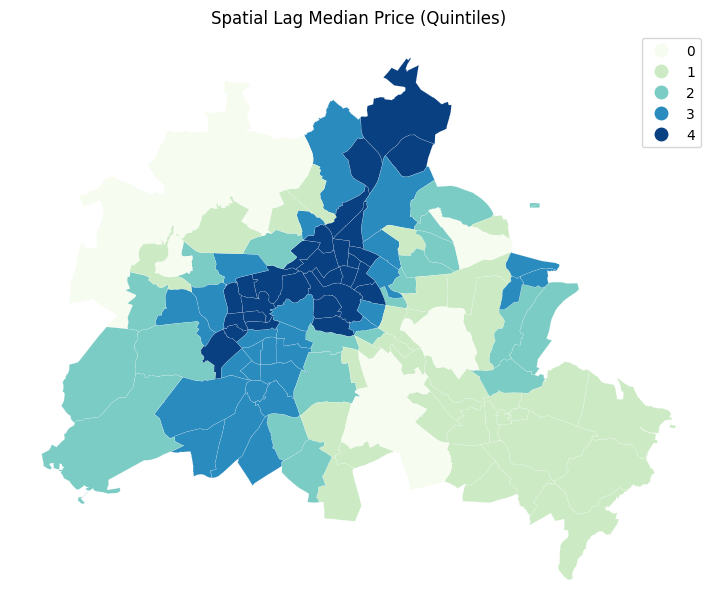

In [14]:
f, ax = plt.subplots(1, figsize=(9, 9))
df.assign(cl=ylagq5.yb).plot(
    column="cl",
    categorical=True,
    k=5,
    cmap="GnBu",
    linewidth=0.1,
    ax=ax,
    edgecolor="white",
    legend=True,
)
ax.set_axis_off()
plt.title("Spatial Lag Median Price (Quintiles)")

plt.show()

The quintile map for the spatial lag tends to enhance the impression of value
similarity in space. It is, in effect, a local smoother.

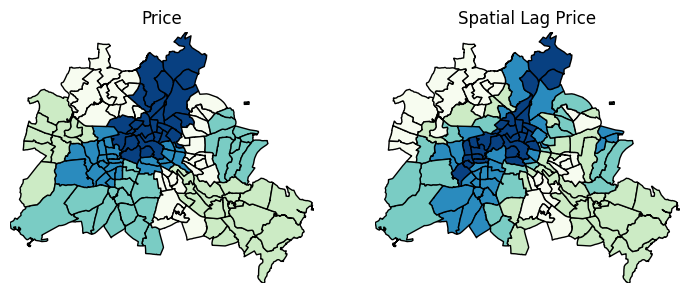

In [15]:
df["lag_median_pri"] = ylag
f, ax = plt.subplots(1, 2, figsize=(2.16 * 4, 4))
df.plot(
    column="median_pri", ax=ax[0], edgecolor="k", scheme="quantiles", k=5, cmap="GnBu"
)
ax[0].axis(df.total_bounds[np.asarray([0, 2, 1, 3])])
ax[0].set_title("Price")
df.plot(
    column="lag_median_pri",
    ax=ax[1],
    edgecolor="k",
    scheme="quantiles",
    cmap="GnBu",
    k=5,
)
ax[1].axis(df.total_bounds[np.asarray([0, 2, 1, 3])])
ax[1].set_title("Spatial Lag Price")
ax[0].axis("off")
ax[1].axis("off")
plt.show()

In [16]:
wq.transform = "r"

Moran's I is a test for global autocorrelation for a continuous attribute:

## Computing global Moran's I

With the outcome and weights in place, we can calculate Moran's $I$. Positive values indicate that similar values are more likely to be neighbors; negative values indicate a checkerboard pattern of dissimilar neighbors.


In [17]:
np.random.seed(12345)
mi = esda.moran.Moran(y, wq)
mi.I

0.6563069331329718

Again, our value for the statistic needs to be interpreted against a reference
distribution under the null of CSR. PySAL uses a similar approach as we saw in
the join count analysis: random spatial permutations.

## Permutation-based inference

The observed value of Moran's $I$ is only meaningful relative to a null model. Here, the null hypothesis is that the observed attribute values are randomly arranged over the fixed neighborhood structure. Permutation inference lets us assess how unusual the observed statistic is under that null.


Text(0.5, 0, "Moran's I")

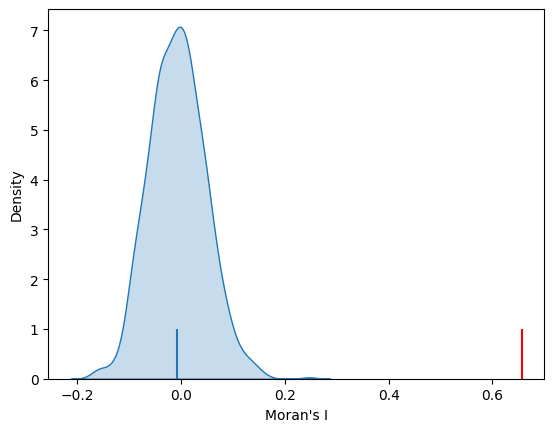

In [18]:
import seaborn as sbn

sbn.kdeplot(mi.sim, fill=True)
plt.vlines(mi.I, 0, 1, color="r")
plt.vlines(mi.EI, 0, 1)
plt.xlabel("Moran's I")

Here our observed value is again in the upper tail, although visually it does
not look as extreme relative to the binary case. Yet, it is still statistically significant:

In [19]:
mi.p_sim

0.001

## Takeaways

This notebook showed how to move from a visual impression of clustering to a formal global test for a continuous variable. In practice, global Moran's $I$ is often the first ESDA step: it tells you whether spatial dependence is present overall, but not **where** it is concentrated. That motivates the local methods in the companion notebook on local spatial autocorrelation.
